# Plot yearly-averaged temperature

A small code that extracts data from the database to show the intermodel min, mean and max yearly-average temperature in Brussels Belgium, per SSP

In [35]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sqlalchemy import text
from src.python import connect_SQL_alchemy

In [36]:
engine = connect_SQL_alchemy()

query = """
WITH annual_gcm_means AS (
    SELECT
        EXTRACT(YEAR FROM time) AS year,
        ssp,
        gcm,
        AVG(value) AS avg_temperature
    FROM belgium_res
    WHERE variable = '2m Temperature'
    GROUP BY
        EXTRACT(YEAR FROM time),
        ssp,
        gcm
)
SELECT
    year,
    ssp,
    AVG(avg_temperature) AS intermodel_avg_avg_temp,
    MAX(avg_temperature) AS intermodel_max_avg_temp,
    MIN(avg_temperature) AS intermodel_min_avg_temp
FROM annual_gcm_means
WHERE year >= 2020
GROUP BY year, ssp
ORDER BY year, ssp;
"""

# Execute and load into DataFrame
df = pd.read_sql_query(query, engine)

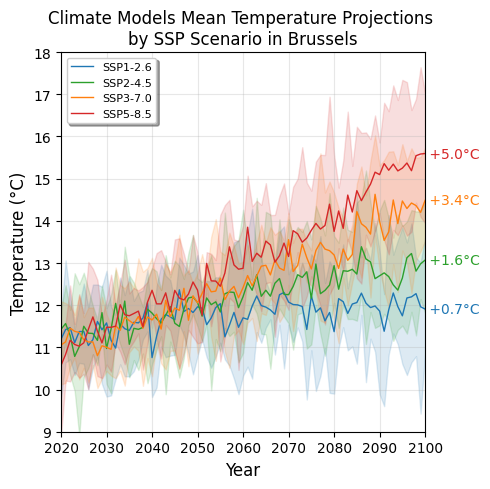

In [37]:
plt.figure(figsize=(5, 5))

# Enhanced color palette
colors = {
    'ssp126': '#1f77b4',  # blue
    'ssp245': '#2ca02c',  # green
    'ssp370': '#ff7f0e',  # orange
    'ssp585': '#d62728'   # red
}

ssp_labels = {
    'ssp126': 'SSP1-2.6',
    'ssp245': 'SSP2-4.5', 
    'ssp370': 'SSP3-7.0',
    'ssp585': 'SSP5-8.5'
}

for ssp in df['ssp'].unique():
    ssp_data = df[df['ssp'] == ssp].sort_values('year')
    
    # Plot shaded area (min to max)
    plt.fill_between(ssp_data['year'], ssp_data['intermodel_min_avg_temp'], ssp_data['intermodel_max_avg_temp'],
                     color=colors[ssp], alpha=0.15)
    
    # Plot mean line
    plt.plot(ssp_data['year'], ssp_data['intermodel_avg_avg_temp'], 
             color=colors[ssp], linewidth=1.0, 
             label=ssp_labels.get(ssp, ssp) #, marker='o', markersize=4
            )
    
    evol = ssp_data['intermodel_avg_avg_temp'].iloc[-1] - ssp_data['intermodel_avg_avg_temp'].iloc[0]
    # Annotation using axis coordinates (0-1 relative to plot area)
    plt.annotate(f" +{np.round(evol,1)}°C", 
                xy=(2100, ssp_data['intermodel_avg_avg_temp'].iloc[-1]), xycoords='data',
                fontsize=10, ha='left', va='center',
                 color = colors[ssp])

plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Climate Models Mean Temperature Projections \nby SSP Scenario in Brussels', fontsize=12)
plt.legend(fontsize=8, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.xlim(2020,2100)
plt.ylim(9,18)
plt.tight_layout()
plt.savefig('Temperature Evolution Belgium.pdf')